# Linear Trend Baseline — SOH 线性外推

这是五档 baseline 中的第 2 个：**Linear Trend（线性外推）**。

核心做法：对每个样本的观测窗口 `X` 中有效的 **SOH** 点拟合

\[
\widehat{SOH}(t)=a t+b
\]

然后从观测窗口末端开始，直接向未来 `Y` 的预测区间外推。

这个 baseline **不使用训练集学习参数**；每条样本都只根据它自己的历史 SOH 拟合直线，因此它是一个非常干净的强基线。

> 注意：当前 `.npz` 文件没有提供 scaler / inverse-transform 参数，因此下面的 MAE、RMSE 等指标都在文件内 SOH 的当前数值尺度上计算。

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


candidates = [
    Path("seq_dataset_10dim_v7.npz"),
    Path("/mnt/data/seq_dataset_10dim_v7.npz"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "找不到 seq_dataset_10dim_v7.npz，请把数据文件放到 notebook 同一目录。"
    )

data = np.load(DATA_PATH, allow_pickle=True)
features = data["features"].tolist()
SOH_IDX = features.index("SOH")

print("Data:", DATA_PATH)
print("Features:", features)
print("SOH index:", SOH_IDX)

Data: seq_dataset_10dim_v7.npz
Features: ['SOH', 'SOC10_R0', 'SOC50_R0', 'SOC90_R0', 'SOC10_R1', 'SOC50_R1', 'SOC90_R1', 'SOC10_R2', 'SOC50_R2', 'SOC90_R2']
SOH index: 0


## 1. 查看数据结构

本数据包含：
- `X`: 观测窗口，形状为 `(samples, 30, 10)`
- `Y`: 未来目标，形状为 `(samples, 29, 10)`
- `X_tmask`: 时间步是否有效
- `X_fmask`: 每个特征是否有效
- `Y_mask`: 每个未来目标是否有效
- `bid`: battery ID

Linear Trend 这里只预测 `SOH`，其他 9 个特征不参与拟合。

In [11]:
for split in ["train", "val", "test"]:
    print(f"\n[{split}]")
    for name in ["X", "X_fmask", "X_tmask", "Y", "Y_mask", "bid"]:
        arr = data[f"{split}_{name}"]
        print(f"{name:8s} shape={arr.shape}, dtype={arr.dtype}")

    obs_len = data[f"{split}_X_tmask"].sum(axis=1)
    y_len = data[f"{split}_Y_mask"][:, :, SOH_IDX].sum(axis=1)
    print(
        "Observed SOH length:",
        f"min={obs_len.min()}, median={np.median(obs_len):.0f}, max={obs_len.max()}"
    )
    print(
        "Future SOH length:",
        f"min={y_len.min()}, median={np.median(y_len):.0f}, max={y_len.max()}"
    )


[train]
X        shape=(4581, 30, 10), dtype=float32
X_fmask  shape=(4581, 30, 10), dtype=bool
X_tmask  shape=(4581, 30), dtype=bool
Y        shape=(4581, 29, 10), dtype=float32
Y_mask   shape=(4581, 29, 10), dtype=bool
bid      shape=(4581,), dtype=int64
Observed SOH length: min=2, median=13, max=30
Future SOH length: min=1, median=12, max=29

[val]
X        shape=(45, 30, 10), dtype=float32
X_fmask  shape=(45, 30, 10), dtype=bool
X_tmask  shape=(45, 30), dtype=bool
Y        shape=(45, 29, 10), dtype=float32
Y_mask   shape=(45, 29, 10), dtype=bool
bid      shape=(45,), dtype=int64
Observed SOH length: min=2, median=11, max=12
Future SOH length: min=3, median=16, max=18

[test]
X        shape=(45, 30, 10), dtype=float32
X_fmask  shape=(45, 30, 10), dtype=bool
X_tmask  shape=(45, 30), dtype=bool
Y        shape=(45, 29, 10), dtype=float32
Y_mask   shape=(45, 29, 10), dtype=bool
bid      shape=(45,), dtype=int64
Observed SOH length: min=2, median=10, max=12
Future SOH length: min=3, medi

## 2. Linear Trend 实现

对于第 `i` 个样本：

1. 用 `X_tmask & X_fmask[..., SOH]` 找到有效 SOH 观测点。
2. 对有效观测点做一元最小二乘直线拟合。
3. 从最后一个观测时间点的下一步开始，对 `Y` 的有效位置外推。
4. 若极端情况下只有 1 个有效观测点，则退化为 persistence（斜率为 0）。

默认使用**全部观测点**拟合，这是最标准、最容易复现的 Linear Trend baseline。

代码保留了两个可选参数：
- `last_k=None`：只用最近 `k` 个观测点拟合；默认不用。
- `force_nonincreasing=False`：若设为 `True`，把正斜率裁剪为 0；纯 baseline 默认不加这个约束。

In [12]:
def fit_linear_trend(t, y, force_nonincreasing=False):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(y) == 0:
        raise ValueError("No valid SOH observation.")
    if len(y) == 1:
        slope = 0.0
        intercept = float(y[0])
        return slope, intercept

    slope, intercept = np.polyfit(t, y, deg=1)

    if force_nonincreasing and slope > 0:
        # SOH 若要求单调不升，则把正斜率裁剪到 0；
        # 此时截距取观测 SOH 的均值，对应固定水平最小二乘解。
        slope = 0.0
        intercept = float(np.mean(y))

    return float(slope), float(intercept)


def predict_one_sample(
    X,
    X_fmask,
    X_tmask,
    Y_mask,
    soh_idx,
    last_k=None,
    force_nonincreasing=False,
):
    # SOH 必须同时满足：该时间步有效 + 该特征有效
    obs_mask = X_tmask.astype(bool) & X_fmask[:, soh_idx].astype(bool)
    obs_pos = np.flatnonzero(obs_mask)
    obs_soh = X[obs_pos, soh_idx].astype(float)

    if last_k is not None and len(obs_pos) > last_k:
        obs_pos = obs_pos[-last_k:]
        obs_soh = obs_soh[-last_k:]

    slope, intercept = fit_linear_trend(
        obs_pos, obs_soh,
        force_nonincreasing=force_nonincreasing
    )

    # Y 的第 j 个槽位表示观测窗口结束后的第 j+1 步
    future_slots = np.flatnonzero(Y_mask[:, soh_idx].astype(bool))
    last_obs_pos = int(obs_pos[-1])
    future_t = last_obs_pos + 1 + future_slots

    pred = intercept + slope * future_t

    return {
        "obs_pos": obs_pos,
        "obs_soh": obs_soh,
        "future_slots": future_slots,
        "future_t": future_t,
        "pred": pred.astype(float),
        "slope": slope,
        "intercept": intercept,
    }

## 3. 对一个样本做 sanity check

这里检查观测窗口末尾、未来真实 SOH 和线性外推的衔接方式是否正确。

In [13]:
split = "val"
i = 0

result = predict_one_sample(
    data[f"{split}_X"][i],
    data[f"{split}_X_fmask"][i],
    data[f"{split}_X_tmask"][i],
    data[f"{split}_Y_mask"][i],
    SOH_IDX,
)

true_future = data[f"{split}_Y"][i, result["future_slots"], SOH_IDX]

print("battery id:", data[f"{split}_bid"][i])
print("n observed:", len(result["obs_pos"]))
print("n future:", len(result["future_slots"]))
print("slope:", result["slope"])
print("last observed SOH:", result["obs_soh"][-1])
print("first 5 true future:", true_future[:5])
print("first 5 predicted:", result["pred"][:5])

battery id: 5
n observed: 11
n future: 17
slope: -0.10686148784377353
last observed SOH: 0.6845628619194031
first 5 true future: [0.64645994 0.570254   0.4749966  0.40831643 0.3321105 ]
first 5 predicted: [0.54825819 0.4413967  0.33453521 0.22767373 0.12081224]


## 4. 整个 split 的预测与评估

下面同时给出：
- **MAE**
- **RMSE**
- **R²**
- 每个未来 horizon 的 MAE / RMSE

总体指标采用所有有效未来 SOH 点 pooled 后计算。

In [14]:
def evaluate_split(
    data,
    split,
    soh_idx,
    last_k=None,
    force_nonincreasing=False,
):
    X = data[f"{split}_X"]
    X_fmask = data[f"{split}_X_fmask"]
    X_tmask = data[f"{split}_X_tmask"]
    Y = data[f"{split}_Y"]
    Y_mask = data[f"{split}_Y_mask"]
    bids = data[f"{split}_bid"]

    rows = []

    for i in range(len(X)):
        r = predict_one_sample(
            X[i],
            X_fmask[i],
            X_tmask[i],
            Y_mask[i],
            soh_idx,
            last_k=last_k,
            force_nonincreasing=force_nonincreasing,
        )

        y_true = Y[i, r["future_slots"], soh_idx].astype(float)

        for slot, t_future, true, pred in zip(
            r["future_slots"], r["future_t"], y_true, r["pred"]
        ):
            rows.append({
                "split": split,
                "sample_idx": i,
                "battery_id": int(bids[i]),
                "n_observed": len(r["obs_pos"]),
                "horizon": int(slot) + 1,
                "time_index": int(t_future),
                "slope": r["slope"],
                "intercept": r["intercept"],
                "y_true": float(true),
                "y_pred": float(pred),
            })

    pred_df = pd.DataFrame(rows)
    err = pred_df["y_pred"] - pred_df["y_true"]

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    ss_res = np.sum(err ** 2)
    y = pred_df["y_true"].to_numpy()
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    metrics = pd.Series({
        "split": split,
        "n_samples": len(X),
        "n_future_points": len(pred_df),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    horizon_metrics = (
        pred_df.assign(abs_error=np.abs(err), sq_error=err ** 2)
        .groupby("horizon", as_index=False)
        .agg(
            n=("y_true", "size"),
            MAE=("abs_error", "mean"),
            MSE=("sq_error", "mean"),
        )
    )
    horizon_metrics["RMSE"] = np.sqrt(horizon_metrics["MSE"])
    horizon_metrics = horizon_metrics.drop(columns="MSE")

    return metrics, horizon_metrics, pred_df

In [15]:
val_metrics, val_horizon, val_pred = evaluate_split(
    data, "val", SOH_IDX
)
test_metrics, test_horizon, test_pred = evaluate_split(
    data, "test", SOH_IDX
)

summary = pd.DataFrame([val_metrics, test_metrics]).set_index("split")
summary

,n_samples,n_future_points,MAE,RMSE,R2
split,,,,,
val,45,662,0.575716,0.772001,0.005895
test,45,622,0.629771,0.833507,-0.248302


## 5. Horizon-wise error

这张图可以看 Linear Trend 随着外推步数变长，误差如何累积。

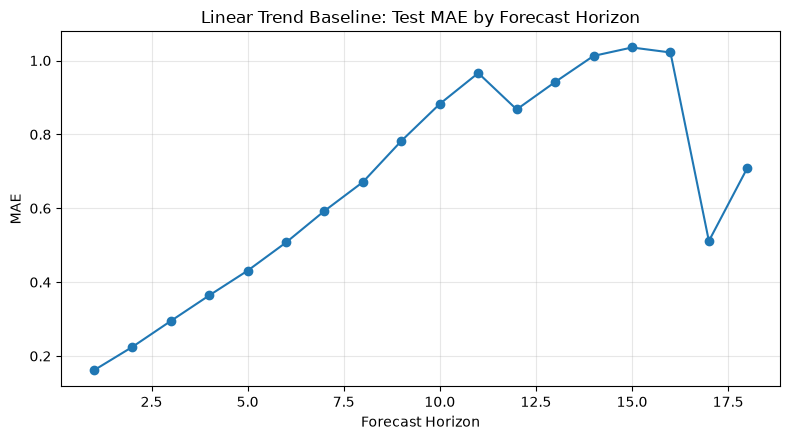

,horizon,n,MAE,RMSE
0,1,45,0.161188,0.213436
1,2,45,0.224493,0.288106
2,3,45,0.294687,0.362617
3,4,42,0.363946,0.443036
4,5,42,0.431022,0.518632
5,6,42,0.507397,0.604879
6,7,42,0.592844,0.704715
7,8,42,0.671046,0.804146
8,9,41,0.782364,0.918177
9,10,41,0.882580,1.031817


In [16]:
plt.figure(figsize=(8, 4.5))
plt.plot(test_horizon["horizon"], test_horizon["MAE"], marker="o")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("Linear Trend Baseline: Test MAE by Forecast Horizon")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_horizon

## 6. 可视化几个 test 样本

每张图单独画：
- observed SOH
- future ground truth
- linear extrapolation

这样可以直接判断线性趋势对不同 battery 的退化轨迹是否偏快或偏慢。

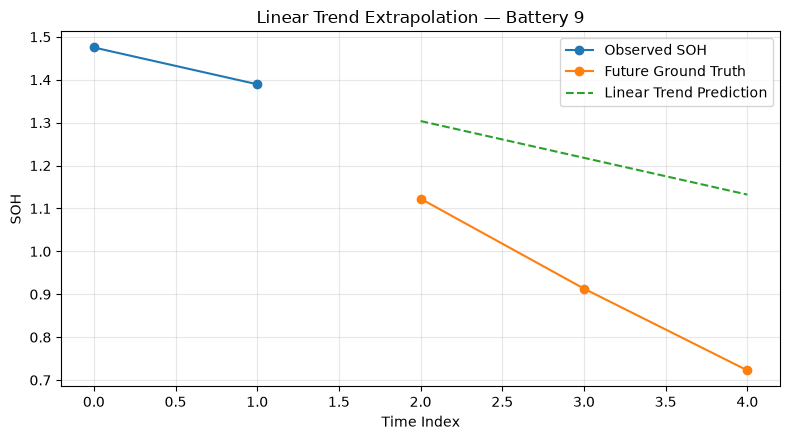

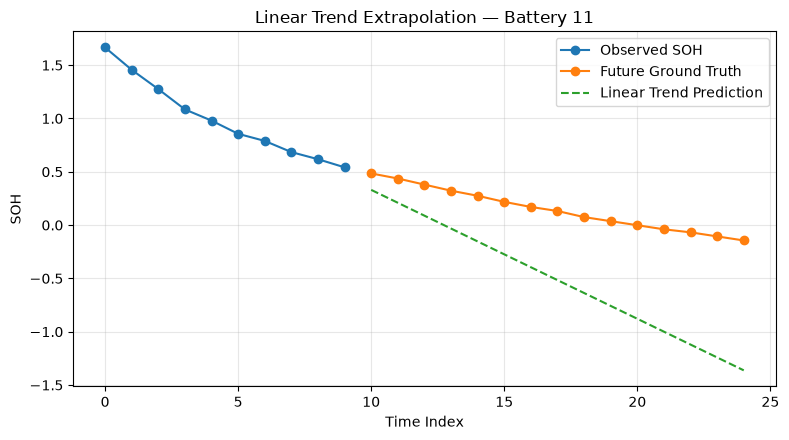

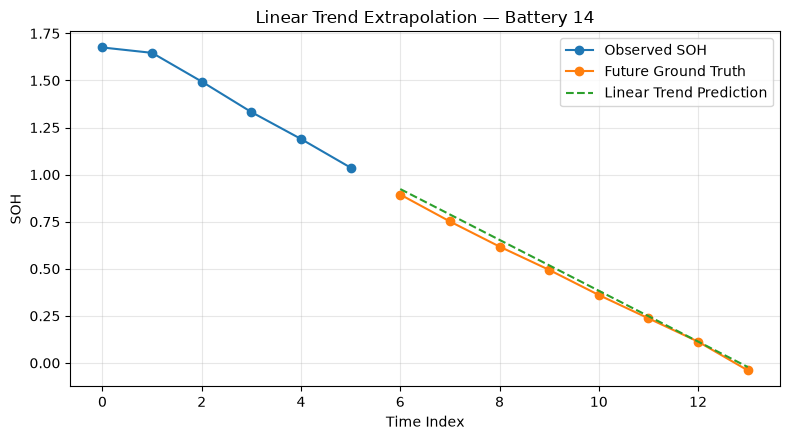

In [17]:
def plot_sample(split, i):
    X = data[f"{split}_X"][i]
    X_fmask = data[f"{split}_X_fmask"][i]
    X_tmask = data[f"{split}_X_tmask"][i]
    Y = data[f"{split}_Y"][i]
    Y_mask = data[f"{split}_Y_mask"][i]
    bid = int(data[f"{split}_bid"][i])

    r = predict_one_sample(
        X, X_fmask, X_tmask, Y_mask, SOH_IDX
    )
    y_true = Y[r["future_slots"], SOH_IDX]

    plt.figure(figsize=(8, 4.5))
    plt.plot(r["obs_pos"], r["obs_soh"], marker="o", label="Observed SOH")
    plt.plot(r["future_t"], y_true, marker="o", label="Future Ground Truth")
    plt.plot(r["future_t"], r["pred"], linestyle="--", label="Linear Trend Prediction")
    plt.xlabel("Time Index")
    plt.ylabel("SOH")
    plt.title(f"Linear Trend Extrapolation — Battery {bid}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


for sample_idx in range(min(3, len(data["test_X"]))):
    plot_sample("test", sample_idx)

## 7. 保存 test 预测结果

CSV 中每一行对应一个有效未来 SOH 点，包含：
`battery_id / horizon / y_true / y_pred / slope / intercept` 等，后面和 Persistence、Ridge、GRU、MTL 放到同一张结果表里会很方便。

In [18]:
OUTPUT_CSV = Path("linear_trend_test_predictions.csv")
test_pred.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV.resolve())

test_pred.head(10)

Saved: \\BIGBOI\ESS\Forschung\bgA\J7099_SIE_Alterung\Studenten\csi-ych\code\电芯数据合集\10维\10维 40%\linear_trend_test_predictions.csv


,split,sample_idx,battery_id,n_observed,horizon,time_index,slope,intercept,y_true,y_pred
0,test,0,9,2,1,2,-0.085732,1.475199,1.122747,1.303736
1,test,0,9,2,2,3,-0.085732,1.475199,0.913181,1.218004
2,test,0,9,2,3,4,-0.085732,1.475199,0.722666,1.132273
3,test,1,11,10,1,10,-0.120890,1.539108,0.484522,0.330205
4,test,1,11,10,2,11,-0.120890,1.539108,0.436894,0.209315
5,test,1,11,10,3,12,-0.120890,1.539108,0.379739,0.088425
6,test,1,11,10,4,13,-0.120890,1.539108,0.322585,-0.032466
7,test,1,11,10,5,14,-0.120890,1.539108,0.274956,-0.153356
8,test,1,11,10,6,15,-0.120890,1.539108,0.217802,-0.274246
9,test,1,11,10,7,16,-0.120890,1.539108,0.170173,-0.395136
